In [1]:
import os
os.chdir('../../..')

print(os.listdir())

['.DS_Store', 'uv.lock', 'config', 'wandb.py', 'pyproject.toml', 'tests', 'utils', 'models', 'README.md', 'results', '.gitignore', 'plot2_qm_properties.png', 'figures', '.venv', 'scripts', 'plot1_structure_weight.png', '.python-version', 'api', 'report', '.git', 'main.py', 'data', 'notebooks', 'plot3_correlation_heatmap.png', 'src']


# This workbook contains results for the Euclidean baseline clustering

In [2]:
import chemiscope
from ase import Atoms  
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import polars as pl
from collections import Counter
import numpy as np
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from rdkit import Chem
from loguru import logger
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
from src.datasets import QM9Dataset
from sklearn.manifold import TSNE

2026-02-24 13:55:47.452 | INFO     | utils.file_ops:get_device:36 - Using Apple Silicon (MPS)


In [3]:
qm9 = QM9Dataset()
qm9.load()
qm9.add_morgan_fingerprints()
qm9.add_selfies_onehot()
qm9.add_selfies_transformer()
qm9.add_chemprop()
qm9.add_soap()
qm9.add_acsf()

2026-02-24 13:55:48.697 | INFO     | src.datasets:_process_raw_qm9:76 - Processing raw QM9 data (Limit: 2000)...
[13:55:49] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:55:49] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:55:49] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:55:50] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:55:50] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:55:50] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:55:51] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:55:52] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:55:53] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:55:53] Explicit valence for atom # 1 C, 5, is greater than permitted
[13:55:53] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:55:53] Explicit valence for atom # 2 C, 5, is greater than permitted
[13:55:53] 

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-02-24 13:56:41.106 | INFO     | src.features:compute_chemprop_embeddings:201 - Computing Chemprop embeddings on mps...
2026-02-24 13:56:41.107 | WARNING  | src.features:compute_chemprop_embeddings:209 - No model_path provided. Using RANDOM (untrained) MPNN weights.
2026-02-24 13:56:42.877 | INFO     | src.features:compute_soap:138 - Computing SOAP (rcut=6.0, nmax=8, lmax=6)...
2026-02-24 13:56:48.230 | SUCCESS  | src.datasets:add_soap:215 - Added SOAP embeddings.
2026-02-24 13:56:48.231 | INFO     | src.features:compute_acsf:168 - Computing ACSF (rcut=6.0)...
2026-02-24 13:56:52.540 | SUCCESS  | src.datasets:add_acsf:225 - Added ACSF embeddings.


In [4]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_onehot,selfies_transformer,chemprop_embedding,soap_embedding,acsf_embedding
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[list[i64]],list[f64],list[f64],list[f64],list[f64]
"""qm9_679""","""[H]C([H])([H])[C@@]1([H])C([H]…","""[H]C([H])([H])[C@@]1([H])C([H]…","""[H][C][Branch1][C][H][Branch1]…",14,"""Aliphatic Ring""",84.118,0.7936,12.53,6,2,0,1,1.0,0,1,5,0,0,5,5,30,0,0,0,0,0,0,0,0,1,0,1,1.8181,52.619999,-6.813731,2.429977,9.243708,504.205505,3.259461,-7357.804199,-7357.652344,-7357.626465,-7358.584473,21.007999,-56.972103,-57.359951,-57.694107,-53.047516,6.51241,3.58887,2.9665,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.281683, 0.138275, … 0.092729]","[0.004791, 0.0, … 0.0]","[0.132517, 0.35926, … 0.0]","[3.943839, 1.059279, … 0.0]"
"""qm9_2151""","""[H]O[C@@]1([H])[C@@]([H])(C([H…","""[H]O[C@@]1([H])[C@@]([H])(C([H…","""[H][O][C@@][Branch1][C][H][C@@…",19,"""Aliphatic Ring""",100.161,1.0232,20.23,7,1,0,3,1.0,1,1,6,0,0,6,6,41,0,1,0,0,0,0,0,0,0,0,1,1.4024,66.360001,-6.772914,1.670779,8.443693,776.933899,4.654889,-8460.367188,-8460.149414,-8460.123047,-8461.231445,30.163,-75.220467,-75.733788,-76.196487,-69.823311,3.12009,2.54906,1.95743,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.080162, 0.517039, … -0.196581]","[0.02787, 0.0, … 0.0]","[0.146165, 0.395404, … 0.0]","[5.024668, 1.216497, … 0.0]"
"""qm9_558""","""[H]OC([H])([H])C1([H])C([H])([…","""[H]OC([H])([H])C1([H])C([H])([…","""[H][O][C][Branch1][C][H][Branc…",16,"""Aliphatic Ring""",86.134,0.7788,20.23,6,1,0,2,1.0,1,1,5,0,0,5,6,34,0,1,0,0,0,0,0,0,0,0,1,1.2955,56.810001,-7.110335,2.108882,9.219218,673.367493,3.903283,-7391.058594,-7390.878418,-7390.852539,-7391.883301,23.882999,-63.000675,-63.437069,-63.822624,-58.540352,8.32944,2.22945,1.91437,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[-0.045379, 0.155783, … -0.140011]","[0.031153, 0.0, … 0.0]","[0.145059, 0.395265, … 0.0]","[4.689672, 1.148579, … 0.0]"
"""qm9_746""","""[H]C1=NN([H])C([H])=C1N([H])[H…","""[H]c1nn([H])c([H])c1N([H])[H]""","""[H][C][=N][N][Branch1][C][H][C…",11,"""Aromatic""",83.094,-0.0081,54.7,6,1,1,1,0.0,2,2,5,0,3,0,5,19,0,0,0,1,0,0,0,0,0,0,3,2.6547,47.66,-5.322547,0.819063,6.14161,479.686401,2.390765,-7659.477051,-7659.33252,-7659.306641,-7660.25,19.370001,-45.914295,-46.193863,-46.450878,-42.82338,9.31893,3.50517,2.55541,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.032143, 0.586472, … 0.013877]","[0.116858, 0.0, … 0.0]","[0.105779, 0.287566, … 0.0]","[2.216341, 0.687717, … 0.0]"
"""qm9_498""","""[H]C(=O)C([H])([H])C#CC([H])([…","""[H]C(=O)C([H])([H])C#CC([H])([…","""[H][C][=Branch1][C][=O][C][Bra…",12,"""Acyclic""",82.102,0.5987,17.07,6,0,0,1,0.4,0,1,3,2,1,2,6,22,0,0,0,0,0,0,0,0,0,0,1,2.7868,55.380001,-6.702164,-0.731986,5.970178,887.423401,2.541897,-7325.810059,-7325.606934,-7325.581055,-7326.721191,23.348,-52.204395,-52.463882,-52.746613,-48.990513,16.144159,1.34674,1.28155,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[-0.044957, 0.554099, … 0.138898]","[0.028065, 0.010707, … 0.0]","[0.115718, 0.311328, … 0.0]","[2.176282, 0.932706, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_1702""","""[H]N1C([H])([H])[C@]1(C([H])([…","""[H]N1C([H])([H])[C@]1(C([H])([…",""

In [5]:
X_morgan = np.array(qm9.df['morgan_fingerprint'].to_list())
X_onehot = np.array(qm9.df['selfies_onehot'].to_list())
X_onehot = X_onehot.reshape(X_onehot.shape[0], -1)
X_transformer = np.array(qm9.df["selfies_transformer"].to_list())
X_chemprop = np.array(qm9.df["chemprop_embedding"].to_list())
X_soap = np.array(qm9.df["soap_embedding"].to_list())
X_acsf = np.array(qm9.df["acsf_embedding"].to_list())

In [6]:
from config.states import get_num_clusters

embeddings = {
    "onehot": X_onehot,
    "morgan": X_morgan,
    "transformer": X_transformer,
    "chemprop": X_chemprop,
    "soap": X_soap,
    "acsf": X_acsf,
}

cluster_labels = {}

for label, X in embeddings.items():
    n_clusters = get_num_clusters(label)

    model = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10,
    )

    cluster_labels[f"{label}_labels"] = model.fit_predict(X)

qm9.df = qm9.df.with_columns(**cluster_labels)

df = qm9.df.drop([
    "morgan_fingerprint",
    "selfies_onehot",
    "selfies_transformer",
    "chemprop_embedding",
    "soap_embedding",
    "acsf_embedding",
])

df.write_csv("report/qm9/euclidean_baseline/csv/qm9_clusterlabels.csv")

In [7]:
def get_structures():
    # Extract both the IDs and the SMILES strings
    mol_ids = qm9.df["mol_id"].to_list()
    smiles_list = qm9.df["canonical_smiles"].to_list()
    
    structures = []  
    valid_indices = [] # We need to track this (see warning below)
    
    for i, (mol_id, s) in enumerate(zip(mol_ids, smiles_list)):
        if s is None:
            print(f"Skipping {mol_id}: SMILES is missing.")
            continue
            
        mol = Chem.MolFromSmiles(s)
        if mol is None: 
            print(f"Skipping {mol_id}: RDKit could not parse SMILES.")
            continue
            
        mol = Chem.AddHs(mol)

        res = AllChem.EmbedMolecule(mol, AllChem.ETKDG())
        if res != 0: 
            print(f"Skipping {mol_id}: Failed to generate 3D conformer.")
            continue

        conf = mol.GetConformer()
        positions = conf.GetPositions()
        numbers = [a.GetAtomicNum() for a in mol.GetAtoms()]
        
        atoms = Atoms(numbers=numbers, positions=positions)
        structures.append(atoms)
        valid_indices.append(i)
        
    return structures, valid_indices


def write_chemiscope(X, label):

    n = get_num_clusters(label)

    structures, valid_indicies = get_structures()

    X = X[valid_indicies]
    model = KMeans(n_clusters=n, random_state=42, n_init=10)
    labels = model.fit_predict(X)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    properties = {
        "PCA 1": X_pca[:, 0],
        "PCA 2": X_pca[:, 1],
        "Cluster": labels,
    }

    output_path = "report/qm9/euclidean_baseline/csv/visualization.json.gz"

    chemiscope.write_input(
        output_path,
        structures=structures,
        properties=properties,
    )
    return output_path

output_path = write_chemiscope(X_soap, 'soap')

- Oxygen: Red
- Nitrogen: Blue
- Hydrogen: White
- Sulfur: Yellow
- Carbon : Grey / Black

In [8]:
chemiscope.show_input(output_path)

<ChemiscopeWidget(meta={'name': 'visualization'}, structures=[{'size': 14, 'data': 'structure-0'}, {'size': 19…

Processing: One-Hot...
Processing: Morgan...
Processing: Transformer...
Processing: ChemProp...
Processing: SOAP...
Processing: ACSF...

Saved to report/qm9/appendix/cluster_metrics.png


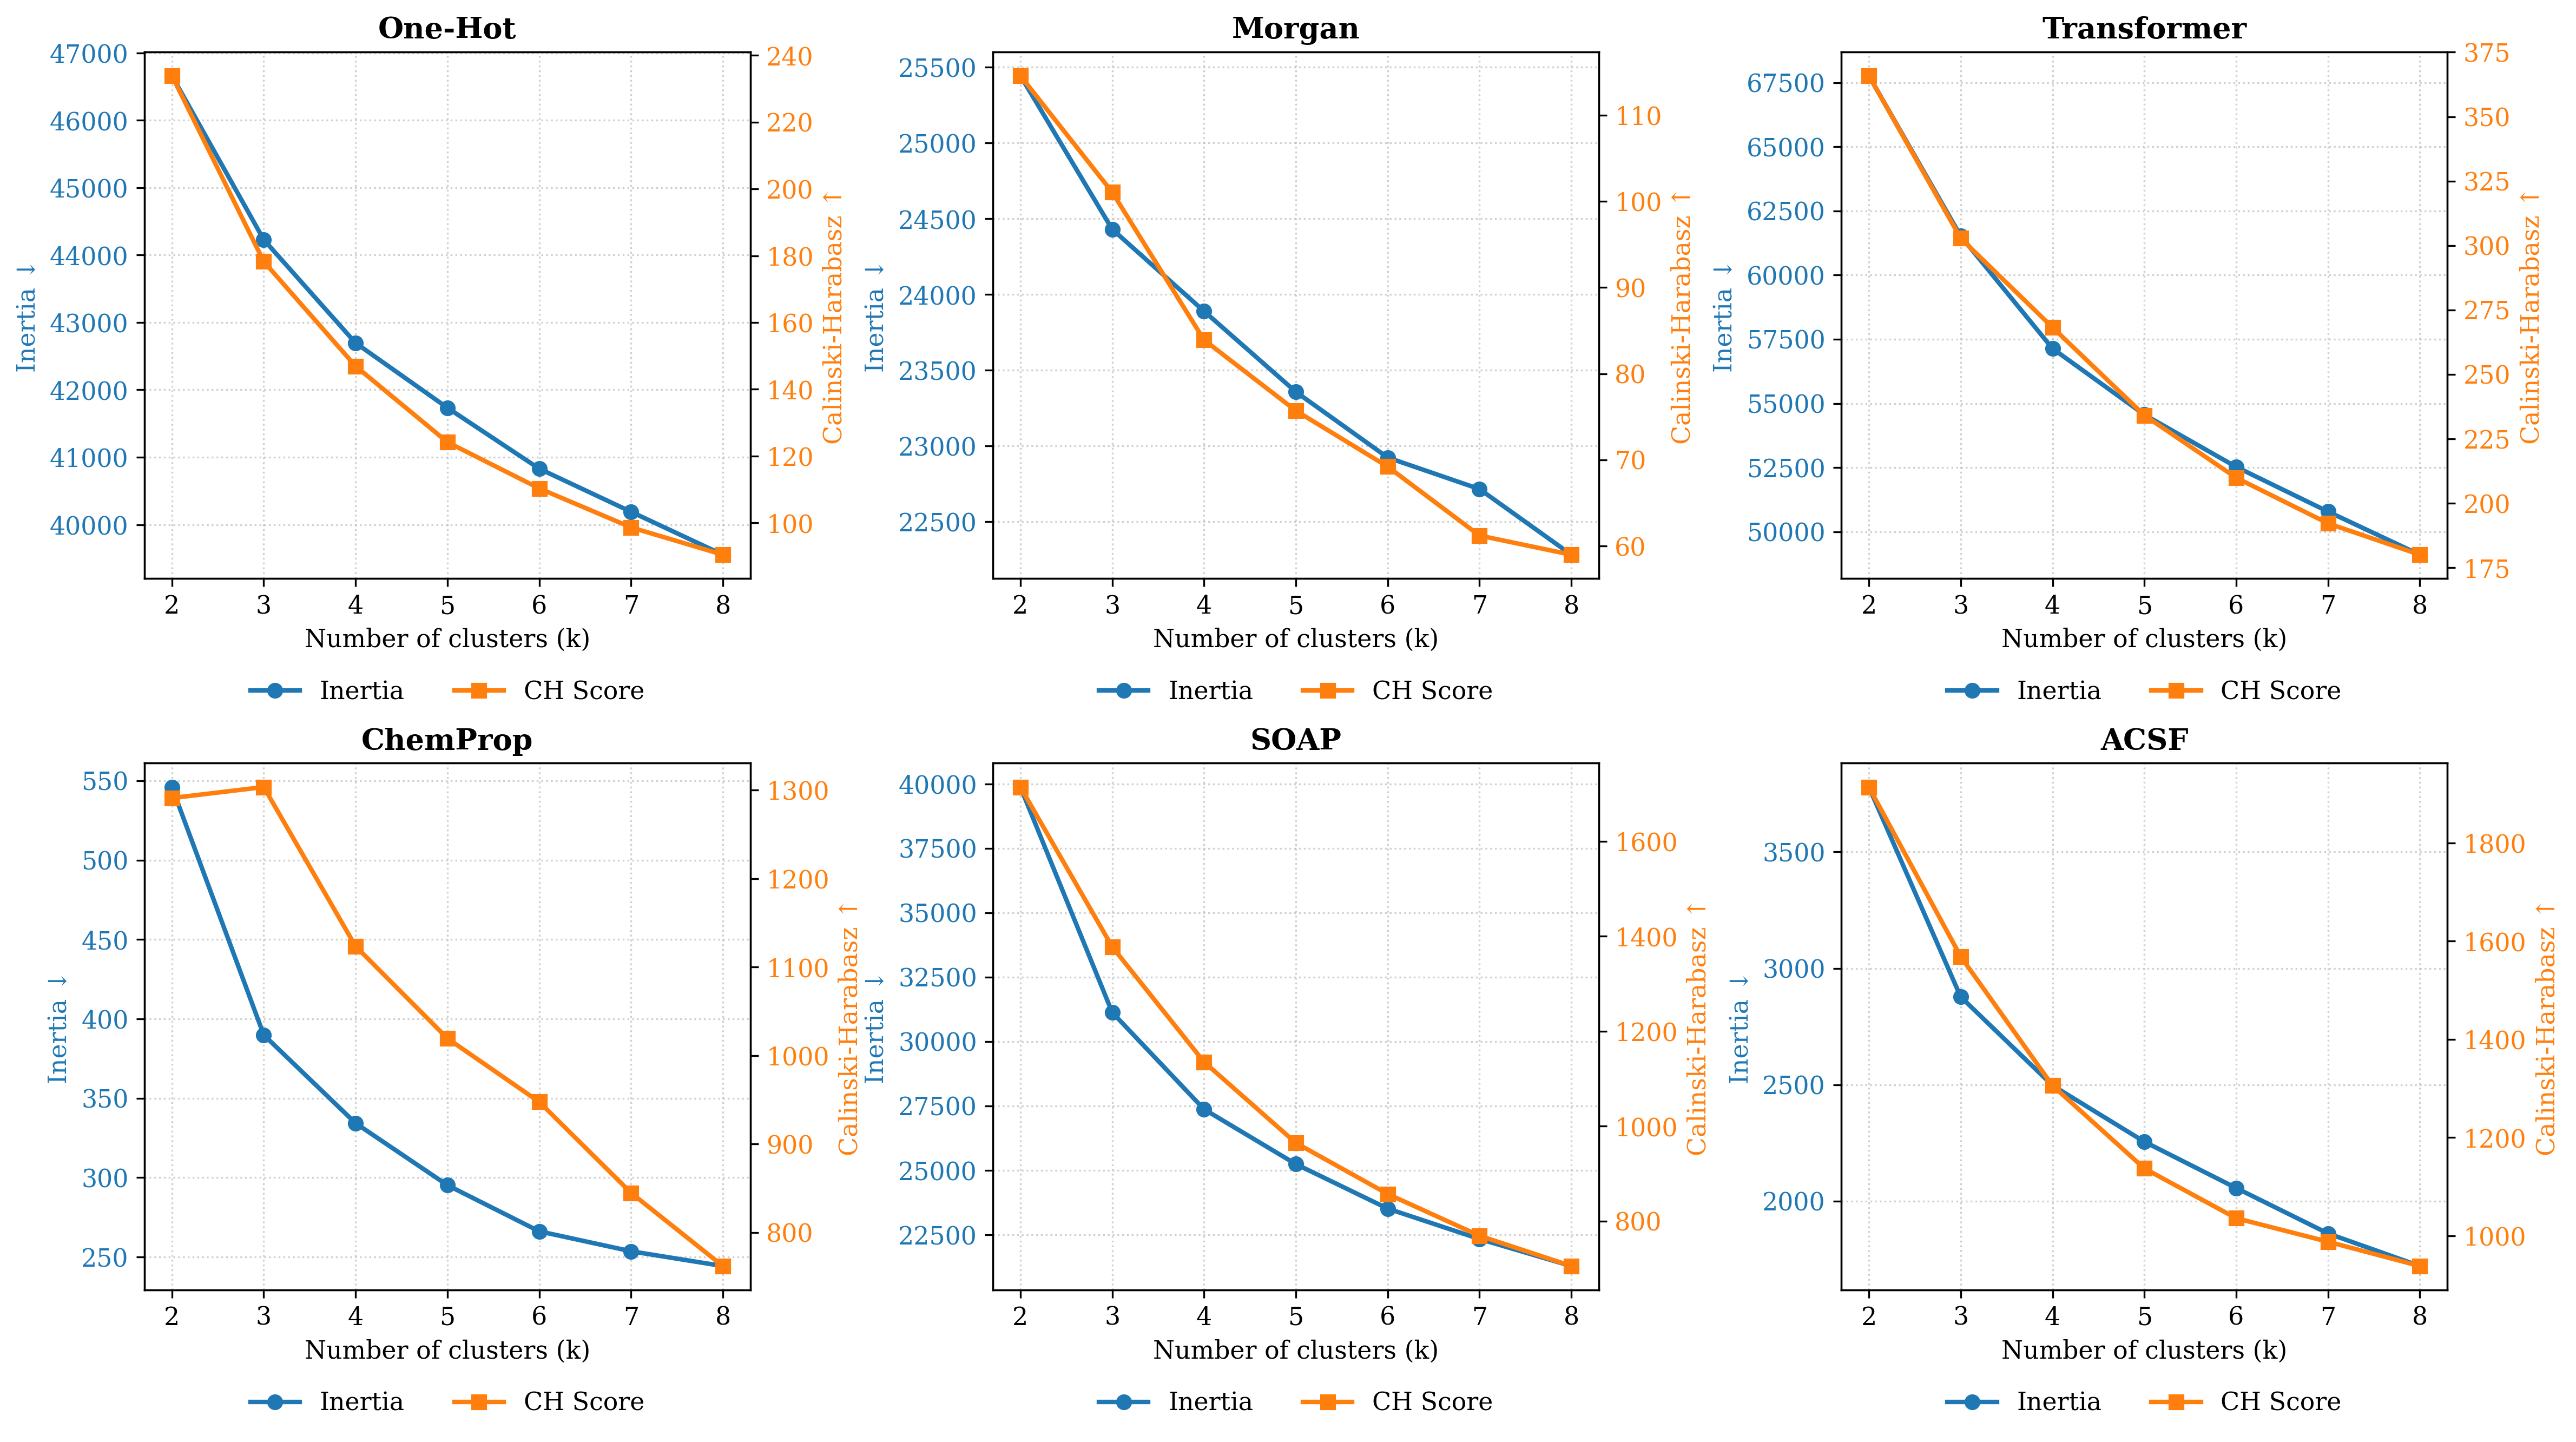

In [9]:
def plot_individual_clustering_metrics(embeddings_dict, max_k=8, save_path=None):
    # Set overall styling for a clean, academic look
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
    })

    k_values = list(range(2, max_k + 1))
    
    # Create a 2x3 grid of subplots for the 6 embeddings
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), dpi=300)
    axes = axes.flatten()

    for idx, (name, X) in enumerate(embeddings_dict.items()):
        print(f"Processing: {name}...")
        ax1 = axes[idx]
        
        inertia_vals = []
        ch_vals = []
        
        for k in k_values:
            model = KMeans(n_clusters=k, random_state=42, n_init=10)
            labels = model.fit_predict(X)
            
            inertia_vals.append(model.inertia_)
            ch_vals.append(calinski_harabasz_score(X, labels))
            
        # 1. Plot Inertia on the primary (left) y-axis
        color1 = '#1f77b4' # Muted Blue
        ax1.set_title(name, fontweight='bold')
        ax1.set_xlabel("Number of clusters (k)")
        ax1.set_ylabel("Inertia ↓", color=color1)
        line1 = ax1.plot(k_values, inertia_vals, marker='o', color=color1, linewidth=2, label="Inertia")
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.set_xticks(k_values)
        ax1.grid(True, linestyle=":", alpha=0.6)
        
        # 2. Plot CH on the secondary (right) y-axis
        ax2 = ax1.twinx()
        color2 = '#ff7f0e' # Muted Orange
        ax2.set_ylabel("Calinski-Harabasz ↑", color=color2)
        line2 = ax2.plot(k_values, ch_vals, marker='s', color=color2, linewidth=2, label="CH Score")
        ax2.tick_params(axis='y', labelcolor=color2)
        
        # 3. Combine legends at the bottom of each subplot
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

    # Hide any unused subplots if you pass fewer than 6 embeddings
    for i in range(idx + 1, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    # Add a little extra vertical space between rows for the legends
    plt.subplots_adjust(hspace=0.35, wspace=0.4)
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"\nSaved to {save_path}")
        
    plt.show()

embeddings = {
    "One-Hot": X_onehot,
    "Morgan": X_morgan,
    "Transformer": X_transformer,
    "ChemProp": X_chemprop,
    "SOAP": X_soap,
    "ACSF": X_acsf
}

plot_individual_clustering_metrics(embeddings, save_path="report/qm9/appendix/cluster_metrics.png")

# Cluster composition analysis

In [10]:
#print(df["morgan_labels"].value_counts(), df["onehot_labels"].value_counts(), df["transformer_labels"].value_counts(), df["chemprop_labels"].value_counts(), df["soap_labels"].value_counts(), df["acsf_labels"].value_counts())

In [15]:
import pandas as pd

def generate_cluster_report(df, label_col, output_csv="cluster_profile.csv"):
    logger.info(f"Generating report for: '{label_col}'...")
    
    # 1. Pre-check: Calculate shape_class if missing but A, B, C are present
    if "shape_class" not in df.columns and "A" in df.columns:
        kappa = (2 * pl.col("B") - pl.col("A") - pl.col("C")) / (pl.col("A") - pl.col("C") + 1e-6)
        df = df.with_columns([
            pl.when((pl.col("A") - pl.col("C")) / pl.col("A") < 0.05).then(pl.lit("Spherical"))
            .when(kappa < -0.8).then(pl.lit("Prolate (Rod)"))
            .when(kappa > 0.8).then(pl.lit("Oblate (Disk)"))
            .otherwise(pl.lit("Asymmetric Top")).alias("shape_class")
        ])

    properties_to_analyze = [
        "mol_weight", "logp", "tpsa", 
        "num_heavy_atoms", "num_rings", "num_aromatic_rings", 
        "num_rotatable_bonds", "fraction_csp3", "h_bond_donors", "h_bond_acceptors",
        "branching_index", "num_sp_carbons", "num_sp2_carbons", "num_sp3_carbons", "main_chain_length", "raw_token_count",
        "fr_benzene", "fr_alcohol", "fr_phenol", "fr_amine", "fr_amide", "fr_carboxylic_acid", "fr_ester", "fr_ketone", "fr_ether", "fr_nitro", "fr_halogen"
    ]
    
    valid_props = [p for p in properties_to_analyze if p in df.columns]
    
    summary = (
        df.group_by(label_col)
        .agg(
            [pl.col(p).mean().alias(f"avg_{p}") for p in valid_props] +
            [pl.len().alias("molecule_count")]
        )
        .sort(label_col)
        .to_pandas()
        .set_index(label_col)
    )
    
    categorical_dfs = []
    for cat_col in ["structure_class", "shape_class"]:
        if cat_col in df.columns:
            pivot = (
                df.group_by([label_col, cat_col])
                .len()
                .pivot(on=cat_col, index=label_col, values="len")
                .fill_null(0)
                .to_pandas()
                .set_index(label_col)
            )
            pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
            pct.columns = [f"pct_{cat_col}_{c}" for c in pct.columns]
            categorical_dfs.append(pct)

    fr_cols = [c for c in df.columns if c.startswith("fr_")]
    fr_profile = df.group_by(label_col).agg([pl.col(c).mean() for c in fr_cols]).sort(label_col).to_pandas().set_index(label_col)
    fr_profile.columns = [f"avg_{c}" for c in fr_profile.columns]

    def get_atom_counts(smiles):
        mol = Chem.MolFromSmiles(smiles)
        return dict(Counter([a.GetSymbol() for a in mol.GetAtoms()])) if mol else {}

    atom_counts = pl.from_dicts(df["smiles"].map_elements(get_atom_counts, return_dtype=pl.Object).to_list()).fill_null(0)
    analysis_df = pl.concat([df.select(label_col), atom_counts], how="horizontal")
    cluster_sums = analysis_df.group_by(label_col).sum().sort(label_col)
    atom_cols = [c for c in cluster_sums.columns if c != label_col]
    total_atoms = cluster_sums.select(atom_cols).sum_horizontal()
    composition = cluster_sums.select([pl.col(label_col)] + [(pl.col(c) / total_atoms * 100).alias(f"pct_atom_{c}") for c in atom_cols]).to_pandas().set_index(label_col)

    final_report = pd.concat([summary] + categorical_dfs + [fr_profile, composition], axis=1)
    final_report = final_report.fillna(0).round(3)
    final_report.to_csv(output_csv)
    logger.success(f"Saved: {output_csv}")
    return final_report

for embedding in ["onehot", "morgan", "transformer", "chemprop", "soap", "acsf"]:
    generate_cluster_report(df, label_col=embedding+'_labels', output_csv=f"report/qm9/euclidean_baseline/csv/{embedding}_profile.csv")

2026-02-24 13:59:59.790 | INFO     | __main__:generate_cluster_report:4 - Generating report for: 'onehot_labels'...
2026-02-24 13:59:59.882 | SUCCESS  | __main__:generate_cluster_report:70 - Saved: report/qm9/euclidean_baseline/csv/onehot_profile.csv
2026-02-24 13:59:59.883 | INFO     | __main__:generate_cluster_report:4 - Generating report for: 'morgan_labels'...
2026-02-24 13:59:59.961 | SUCCESS  | __main__:generate_cluster_report:70 - Saved: report/qm9/euclidean_baseline/csv/morgan_profile.csv
2026-02-24 13:59:59.962 | INFO     | __main__:generate_cluster_report:4 - Generating report for: 'transformer_labels'...
2026-02-24 14:00:00.042 | SUCCESS  | __main__:generate_cluster_report:70 - Saved: report/qm9/euclidean_baseline/csv/transformer_profile.csv
2026-02-24 14:00:00.043 | INFO     | __main__:generate_cluster_report:4 - Generating report for: 'chemprop_labels'...
2026-02-24 14:00:00.129 | SUCCESS  | __main__:generate_cluster_report:70 - Saved: report/qm9/euclidean_baseline/csv/che

In [12]:
os.listdir()

['.DS_Store',
 'uv.lock',
 'config',
 'wandb.py',
 'pyproject.toml',
 'tests',
 'utils',
 'models',
 'README.md',
 'results',
 '.gitignore',
 'plot2_qm_properties.png',
 'figures',
 '.venv',
 'scripts',
 'plot1_structure_weight.png',
 '.python-version',
 'api',
 'report',
 '.git',
 'main.py',
 'data',
 'notebooks',
 'plot3_correlation_heatmap.png',
 'src']

In [13]:
qm9.df

mol_id,smiles,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,fr_halogen,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,selfies_onehot,selfies_transformer,chemprop_embedding,soap_embedding,acsf_embedding,onehot_labels,morgan_labels,transformer_labels,chemprop_labels,soap_labels,acsf_labels
str,str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],list[list[i64]],list[f64],list[f64],list[f64],list[f64],i32,i32,i32,i32,i32,i32
"""qm9_679""","""[H]C([H])([H])[C@@]1([H])C([H]…","""[H]C([H])([H])[C@@]1([H])C([H]…","""[H][C][Branch1][C][H][Branch1]…",14,"""Aliphatic Ring""",84.118,0.7936,12.53,6,2,0,1,1.0,0,1,5,0,0,5,5,30,0,0,0,0,0,0,0,0,1,0,1,1.8181,52.619999,-6.813731,2.429977,9.243708,504.205505,3.259461,-7357.804199,-7357.652344,-7357.626465,-7358.584473,21.007999,-56.972103,-57.359951,-57.694107,-53.047516,6.51241,3.58887,2.9665,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.281683, 0.138275, … 0.092729]","[0.004791, 0.0, … 0.0]","[0.132517, 0.35926, … 0.0]","[3.943839, 1.059279, … 0.0]",1,1,0,0,1,0
"""qm9_2151""","""[H]O[C@@]1([H])[C@@]([H])(C([H…","""[H]O[C@@]1([H])[C@@]([H])(C([H…","""[H][O][C@@][Branch1][C][H][C@@…",19,"""Aliphatic Ring""",100.161,1.0232,20.23,7,1,0,3,1.0,1,1,6,0,0,6,6,41,0,1,0,0,0,0,0,0,0,0,1,1.4024,66.360001,-6.772914,1.670779,8.443693,776.933899,4.654889,-8460.367188,-8460.149414,-8460.123047,-8461.231445,30.163,-75.220467,-75.733788,-76.196487,-69.823311,3.12009,2.54906,1.95743,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.080162, 0.517039, … -0.196581]","[0.02787, 0.0, … 0.0]","[0.146165, 0.395404, … 0.0]","[5.024668, 1.216497, … 0.0]",3,1,2,0,3,0
"""qm9_558""","""[H]OC([H])([H])C1([H])C([H])([…","""[H]OC([H])([H])C1([H])C([H])([…","""[H][O][C][Branch1][C][H][Branc…",16,"""Aliphatic Ring""",86.134,0.7788,20.23,6,1,0,2,1.0,1,1,5,0,0,5,6,34,0,1,0,0,0,0,0,0,0,0,1,1.2955,56.810001,-7.110335,2.108882,9.219218,673.367493,3.903283,-7391.058594,-7390.878418,-7390.852539,-7391.883301,23.882999,-63.000675,-63.437069,-63.822624,-58.540352,8.32944,2.22945,1.91437,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[-0.045379, 0.155783, … -0.140011]","[0.031153, 0.0, … 0.0]","[0.145059, 0.395265, … 0.0]","[4.689672, 1.148579, … 0.0]",3,1,0,0,1,0
"""qm9_746""","""[H]C1=NN([H])C([H])=C1N([H])[H…","""[H]c1nn([H])c([H])c1N([H])[H]""","""[H][C][=N][N][Branch1][C][H][C…",11,"""Aromatic""",83.094,-0.0081,54.7,6,1,1,1,0.0,2,2,5,0,3,0,5,19,0,0,0,1,0,0,0,0,0,0,3,2.6547,47.66,-5.322547,0.819063,6.14161,479.686401,2.390765,-7659.477051,-7659.33252,-7659.306641,-7660.25,19.370001,-45.914295,-46.193863,-46.450878,-42.82338,9.31893,3.50517,2.55541,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[0.032143, 0.586472, … 0.013877]","[0.116858, 0.0, … 0.0]","[0.105779, 0.287566, … 0.0]","[2.216341, 0.687717, … 0.0]",2,2,3,2,2,1
"""qm9_498""","""[H]C(=O)C([H])([H])C#CC([H])([…","""[H]C(=O)C([H])([H])C#CC([H])([…","""[H][C][=Branch1][C][=O][C][Bra…",12,"""Acyclic""",82.102,0.5987,17.07,6,0,0,1,0.4,0,1,3,2,1,2,6,22,0,0,0,0,0,0,0,0,0,0,1,2.7868,55.380001,-6.702164,-0.731986,5.970178,887.423401,2.541897,-7325.810059,-7325.606934,-7325.581055,-7326.721191,23.348,-52.204395,-52.463882,-52.746613,-48.990513,16.144159,1.34674,1.28155,"[0, 0, … 0]","[[0, 0, … 0], [0, 0, … 0], … [0, 0, … 1]]","[-0.044957, 0.554099, … 0.138898]","[0.028065, 0.010707, … 0.0]","[0.115718, 0.311328, … 0.0]","[2.176282, 0.932706, … 0.0]",2,0,1,1,2,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,